In [1]:
import numpy as np
import os
import xarray as xr
import Ngl
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from matplotlib.dates import DateFormatter, HourLocator, date2num, num2date

# global constants
g = 9.81

PERTURB_DIR = '/glade/derecho/scratch/nforcone/CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Perturbation_New/run'
FILE_PERTURB_MONTHLY = 'CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Perturbation_New.cam.h0a.0001-01-31-00000.nc'
perturbation = xr.open_dataset(os.path.join(PERTURB_DIR, FILE_PERTURB_MONTHLY), decode_cf=False)

CONTROL_DIR = '/glade/derecho/scratch/nforcone/CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Control_New/run'
FILE_CONTROL_MONTHLY = 'CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Control_New.cam.h0a.0001-01-31-00000.nc'
control = xr.open_dataset(os.path.join(CONTROL_DIR, FILE_CONTROL_MONTHLY), decode_cf=False)

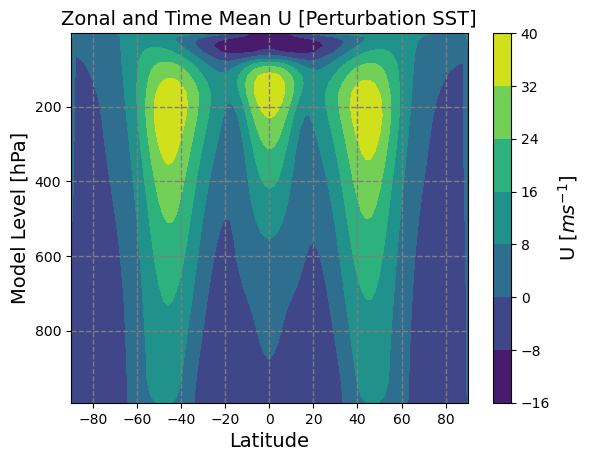

In [2]:
# def my_plotter(ax, data1, data2, param_dict):
#     """
#     A helper function to make a graph.
#     """
#     out = ax.plot(data1, data2, **param_dict)
#     return out

# data1, data2, data3, data4 = np.random.randn(4, 100)  # make 4 random data sets
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.7))
# my_plotter(ax1, data1, data2, {'marker': 'x'})
# my_plotter(ax2, data3, data4, {'marker': 'o'})

def lat_lev_U_plot(ax, xr_dataset, title='Set Title'):
    label_size = 14

    # DISCARD FIRST 5 MONTHS
    U = xr_dataset.U[5:,:,:,:]
    
    CF = ax.contourf(xr_dataset.lat, xr_dataset.lev, U.mean(dim=['time','lon']))
    cb = plt.colorbar(CF, ax=ax)
    cb.set_label(r'U [$m s^{-1}$]', size=label_size)
    plt.grid(color='tab:gray', linestyle='--', linewidth=1)
    plt.title(title, size=label_size)
    ax.set_xlabel('Latitude', size=label_size)
    ax.set_ylabel('Model Level [hPa]', size=label_size)
    ax.invert_yaxis()

# perturbation SST
perturb_u_fig, perturb_u_ax = plt.subplots()
lat_lev_U_plot(perturb_u_ax, perturbation, 'Zonal and Time Mean U [Perturbation SST]')

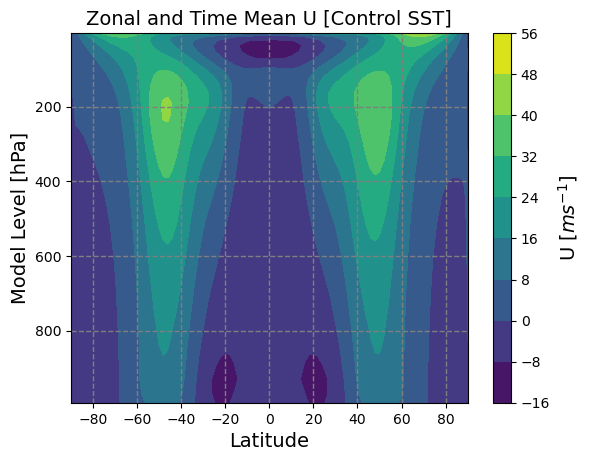

In [3]:
# control SST
control_u_fig, control_u_ax = plt.subplots()
lat_lev_U_plot(control_u_ax, control, 'Zonal and Time Mean U [Control SST]')

$$\overline{vT}=\overline{v}\overline{T}+\overline{v'T'}$$

$$[\overline{vT}]=[\overline{v}][\overline{T}]+[\overline{v}^*\overline{T}^*]+[\overline{v'T'}]$$

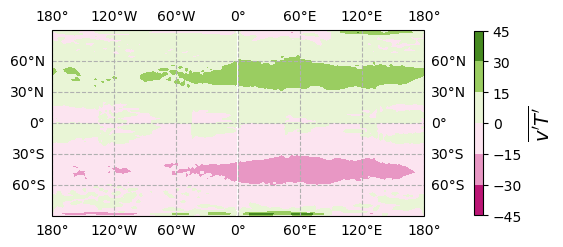

In [17]:
def plot_VT_decomp(ax, xr_dataset, lev, title='Set Title'):
    label_size = 14
    VT = xr_dataset.VT[5:,:,:,:].mean(dim='time')
    V = xr_dataset.V[5:,:,:,:].mean(dim='time')
    T = xr_dataset.T[5:,:,:,:].mean(dim='time')
    V_prime_T_prime = VT - V * T
    CF = ax.contourf(xr_dataset.lon, xr_dataset.lat, V_prime_T_prime[:,:,:].sel(lev=lev, method='nearest'), cmap='PiYG')
    ax.gridlines(draw_labels=True, linestyle='--')
    cb = plt.colorbar(CF, ax=ax, shrink=0.5, pad=0.1)
    cb.set_label(r"$\overline{v'T'}$", size=label_size)

# perturbation SST
VT_perturb_fig = plt.figure()
VT_perturb_ax = plt.axes(projection=ccrs.PlateCarree())
plot_VT_decomp(VT_perturb_ax, perturbation, lev=850)

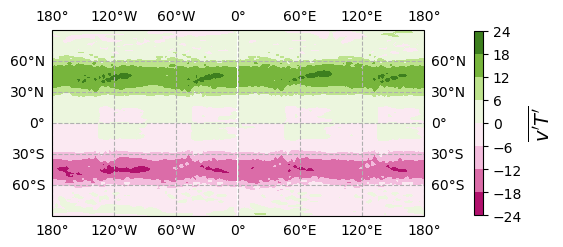

In [18]:
# control SST
VT_control_fig = plt.figure()
VT_control_ax = plt.axes(projection=ccrs.PlateCarree())
plot_VT_decomp(VT_control_ax, control, lev=850)

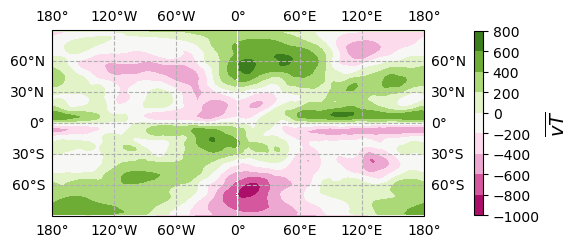

In [6]:
def plot_VT(ax, xr_dataset, lev, title='Set Title'):
    label_size = 14
    VT = xr_dataset.VT[5:,:,:,:].mean(dim='time')
    CF = ax.contourf(xr_dataset.lon, xr_dataset.lat, VT[:,:,:].sel(lev=lev, method='nearest'), cmap='PiYG')
    ax.gridlines(draw_labels=True, linestyle='--')
    cb = plt.colorbar(CF, ax=ax, shrink=0.5, pad=0.1)
    cb.set_label(r"$\overline{vT}$", size=label_size)

# perturbation SST
VT_perturb_fig = plt.figure()
VT_perturb_ax = plt.axes(projection=ccrs.PlateCarree())
plot_VT(VT_perturb_ax, perturbation, lev=850)

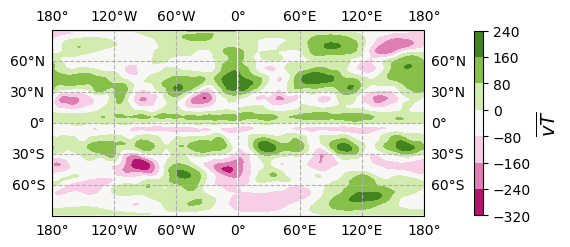

In [7]:
# control SST
VT_control_fig = plt.figure()
VT_control_ax = plt.axes(projection=ccrs.PlateCarree())
plot_VT(VT_control_ax, control, lev=850)

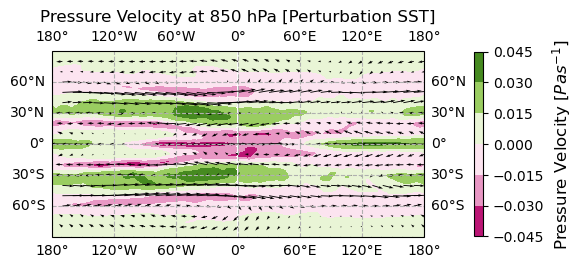

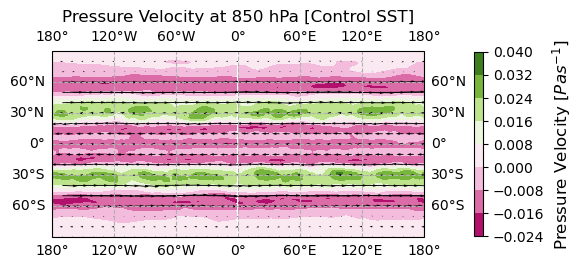

In [7]:
def plot_OMEGA850(ax, xr_dataset, title='Set Title'):
    skip = 5
    label_size = 12

    # DISCARD FIRST 5 MONTHS
    OMEGA850 = xr_dataset.OMEGA850[5:,:,:].mean(dim='time')
    U = xr_dataset.U[5:,:,::skip,::skip].mean(dim='time')
    V = xr_dataset.V[5:,:,::skip,::skip].mean(dim='time')
    
    CF = ax.contourf(xr_dataset.lon, xr_dataset.lat, OMEGA850, cmap='PiYG')
    ax.quiver(xr_dataset.lon[::skip], xr_dataset.lat[::skip], U.sel(lev=850, method='nearest'), V.sel(lev=850, method='nearest'))
    ax.gridlines(draw_labels=True, linestyle='--')
    cb = plt.colorbar(CF, ax=ax, shrink=0.5, pad=0.1)
    cb.set_label(r'Pressure Velocity [$Pa s^{-1}$]', size=label_size)
    plt.title(title)

# perturbation SST
OMEGA850_perturb_fig = plt.figure()
OMEGA850_perturb_ax = plt.axes(projection=ccrs.PlateCarree())
plot_OMEGA850(OMEGA850_perturb_ax, perturbation, 'Pressure Velocity at 850 hPa [Perturbation SST]')

# control SST
OMEGA850_control_fig = plt.figure()
OMEGA850_control_ax = plt.axes(projection=ccrs.PlateCarree())
plot_OMEGA850(OMEGA850_control_ax, control, 'Pressure Velocity at 850 hPa [Control SST]')

In [8]:
control

<xarray.Dataset> Size: 1GB
Dimensions:       (lat: 91, lon: 180, lev: 26, ilev: 27, trop_pref: 26,
                   trop_prefi: 27, time: 36, nbnd: 2, chars: 8)
Coordinates:
  * lat           (lat) float64 728B -90.0 -88.0 -86.0 -84.0 ... 86.0 88.0 90.0
  * lon           (lon) float64 1kB 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * lev           (lev) float64 208B 3.545 7.389 13.97 ... 929.6 970.6 992.6
  * ilev          (ilev) float64 216B 2.194 4.895 9.882 ... 956.0 985.1 1e+03
  * trop_pref     (trop_pref) float64 208B 3.545 7.389 13.97 ... 970.6 992.6
  * trop_prefi    (trop_prefi) float64 216B 2.194 4.895 9.882 ... 985.1 1e+03
  * time          (time) float64 288B 15.0 45.0 75.0 ... 1.035e+03 1.065e+03
Dimensions without coordinates: nbnd, chars
Data variables: (12/44)
    w             (lat) float64 728B ...
    hyam          (lev) float64 208B ...
    hybm          (lev) float64 208B ...
    hyai          (ilev) float64 216B ...
    hybi          (ilev) float64 216B ...
    date          (time) int32 144B ...
    ...            ...
    VV            (time, lev, lat, lon) float32 61MB ...
    Z3            (time, lev, lat, lon) float32 61MB ...
    ZZ            (time, lev, lat, lon) float32 61MB ...
    TT            (time, lev, lat, lon) float32 61MB ...
    VQ            (time, lev, lat, lon) float32 61MB ...
    QQ            (time, lev, lat, lon) float32 61MB ...
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Control_New
    logname:           nforcone
    host:              dec0097
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/s...
    topography_file:   bnd_topo
    model_doi_url:     not_set
    time_period_freq:  day_30

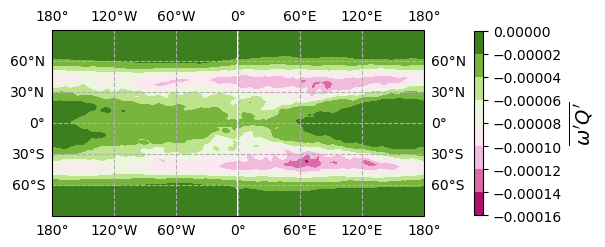

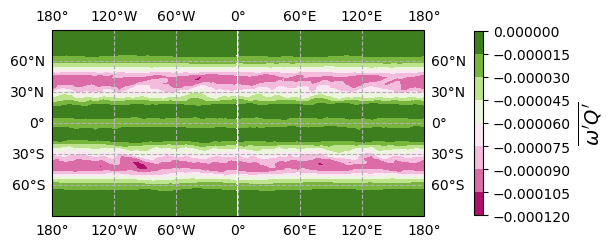

In [23]:
def plot_OMEGAQ_decomp(ax, xr_dataset, lev, title='Set Title'):
    label_size = 14
    OMEGAQ = xr_dataset.OMEGAQ[5:,:,:,:].mean(dim='time')
    OMEGA = xr_dataset.OMEGA[5:,:,:,:].mean(dim='time')
    Q = xr_dataset.Q[5:,:,:,:].mean(dim='time')
    OMEGA_prime_Q_prime = OMEGAQ - OMEGA * Q
    CF = ax.contourf(xr_dataset.lon, xr_dataset.lat, OMEGA_prime_Q_prime[:,:,:].sel(lev=lev, method='nearest'), cmap='PiYG')
    ax.gridlines(draw_labels=True, linestyle='--')
    cb = plt.colorbar(CF, ax=ax, shrink=0.5, pad=0.1)
    cb.set_label(r"$\overline{\omega'Q'}$", size=label_size)

# perturbation SST
OMEGAQ_perturb_fig = plt.figure()
OMEGAQ_perturb_ax = plt.axes(projection=ccrs.PlateCarree())
plot_OMEGAQ_decomp(OMEGAQ_perturb_ax, perturbation, lev=850)

# control SST
OMEGAQ_control_fig = plt.figure()
OMEGAQ_control_ax = plt.axes(projection=ccrs.PlateCarree())
plot_OMEGAQ_decomp(OMEGAQ_control_ax, control, lev=850)

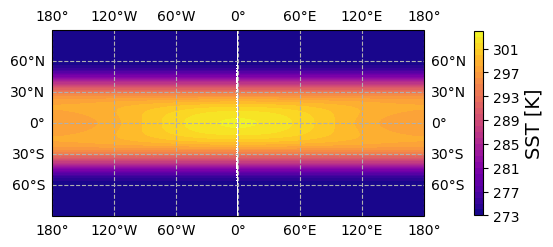

In [40]:
def plot_SST(ax, xr_dataset, lev, title='Set Title'):
    label_size = 14
    SST = xr_dataset.SST[0,:,:]  # does not change in time
    CF = ax.contourf(xr_dataset.lon, xr_dataset.lat, SST, cmap='plasma', levels=30)
    ax.gridlines(draw_labels=True, linestyle='--')
    cb = plt.colorbar(CF, ax=ax, shrink=0.5, pad=0.1)
    cb.set_label("SST [K]", size=label_size)

# perturbation SST
SST_perturb_fig = plt.figure()
SST_perturb_ax = plt.axes(projection=ccrs.PlateCarree())
plot_SST(SST_perturb_ax, perturbation, lev=850)

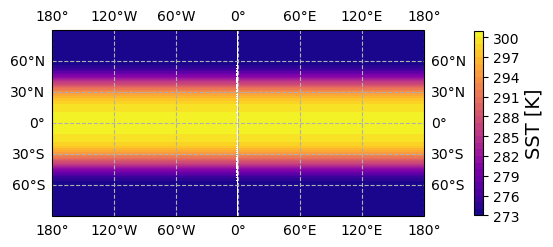

In [41]:
# control SST
SST_control_fig = plt.figure()
SST_control_ax = plt.axes(projection=ccrs.PlateCarree())
plot_SST(SST_control_ax, control, lev=850)

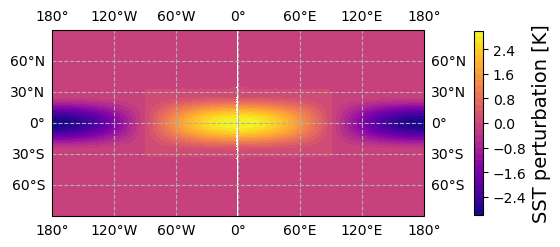

In [38]:
SST_diff = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
label_size = 14
SST_perturb = perturbation.SST[0,:,:]  # does not change in time
SST_control = control.SST[0,:,:]  # does not change in time
CF = ax.contourf(control.lon, control.lat, SST_perturb-SST_control, cmap='plasma', levels=30)
ax.gridlines(draw_labels=True, linestyle='--')
cb = plt.colorbar(CF, ax=ax, shrink=0.5, pad=0.1)
cb.set_label("SST perturbation [K]", size=label_size)

In [48]:
control

<xarray.Dataset> Size: 1GB
Dimensions:       (lat: 91, lon: 180, lev: 26, ilev: 27, trop_pref: 26,
                   trop_prefi: 27, time: 36, nbnd: 2, chars: 8)
Coordinates:
  * lat           (lat) float64 728B -90.0 -88.0 -86.0 -84.0 ... 86.0 88.0 90.0
  * lon           (lon) float64 1kB 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * lev           (lev) float64 208B 3.545 7.389 13.97 ... 929.6 970.6 992.6
  * ilev          (ilev) float64 216B 2.194 4.895 9.882 ... 956.0 985.1 1e+03
  * trop_pref     (trop_pref) float64 208B 3.545 7.389 13.97 ... 970.6 992.6
  * trop_prefi    (trop_prefi) float64 216B 2.194 4.895 9.882 ... 985.1 1e+03
  * time          (time) float64 288B 15.0 45.0 75.0 ... 1.035e+03 1.065e+03
Dimensions without coordinates: nbnd, chars
Data variables: (12/44)
    w             (lat) float64 728B ...
    hyam          (lev) float64 208B ...
    hybm          (lev) float64 208B ...
    hyai          (ilev) float64 216B ...
    hybi          (ilev) float64 216B ...
    date          (time) int32 144B ...
    ...            ...
    VV            (time, lev, lat, lon) float32 61MB ...
    Z3            (time, lev, lat, lon) float32 61MB ...
    ZZ            (time, lev, lat, lon) float32 61MB ...
    TT            (time, lev, lat, lon) float32 61MB ...
    VQ            (time, lev, lat, lon) float32 61MB ...
    QQ            (time, lev, lat, lon) float32 61MB ...
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Control_New
    logname:           nforcone
    host:              dec0097
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/s...
    topography_file:   bnd_topo
    model_doi_url:     not_set
    time_period_freq:  day_30